In [ ]:
import json
import random
import pandas as pd
import os
import argparse

def generate_labeled_requests(policy_json, num_allow=3, num_deny=2):
    policy = json.loads(policy_json)
    statements = policy.get("Statement", [])
    requests = []

    # Helper functions to extract and normalize values
    def get_action(stmt):
        action = stmt.get("Action")
        if action is None:
            # If no action specified, extract service from other actions in policy or use generic
            all_actions = []
            for s in statements:
                stmt_actions = s.get("Action", [])
                if isinstance(stmt_actions, list):
                    all_actions.extend(stmt_actions)
                elif stmt_actions:
                    all_actions.append(stmt_actions)
            
            if all_actions:
                # Use an action from the policy
                return random.choice(all_actions)
            else:
                # Fallback to generic action
                return "*"
        
        # Preserve list structure
        if isinstance(action, list):
            return action  # Return the entire list
        return action  # Return single string

    def get_resource(stmt):
        resource = stmt.get("Resource")
        if resource is None:
            # If no resource specified, extract from other statements or use generic
            all_resources = []
            for s in statements:
                stmt_resources = s.get("Resource", [])
                if isinstance(stmt_resources, list):
                    all_resources.extend(stmt_resources)
                elif stmt_resources:
                    all_resources.append(stmt_resources)
            
            if all_resources:
                # Use a resource from the policy
                resource = random.choice(all_resources)
            else:
                # Fallback to generic resource
                resource = "*"
        
        # Preserve list structure
        if isinstance(resource, list):
            # Process each resource in the list
            processed_resources = []
            for res in resource:
                if "*" in res:
                    processed_resources.append(res.replace("*", f"object-{random.randint(1, 100)}"))
                else:
                    processed_resources.append(res)
            return processed_resources
        else:
            # Single resource
            if "*" in resource:
                return resource.replace("*", f"object-{random.randint(1, 100)}")
            return resource

    def get_principal(stmt):
        principal = stmt.get("Principal")
        if principal is None:
            # If no principal specified, use a generic one
            return "arn:aws:iam::123456789012:user/generic-user"
        
        if isinstance(principal, dict):
            # Handle {"AWS": "arn:..."} or {"AWS": ["arn1", "arn2"]} format
            values = list(principal.values())[0]
            return values  # Preserve list structure if it exists
        return principal  # Return as-is (could be string or list)

    def get_condition(stmt):
        cond_block = stmt.get("Condition", {})
        if not cond_block:
            # If no conditions in this statement, return empty dict (no default condition)
            return {}
        
        flattened = {}
        for operator, conds in cond_block.items():
            for key, val in conds.items():
                if isinstance(val, (int, float)):
                    flattened[key] = val + 1  # Slightly modify to ensure it should still pass
                else:
                    flattened[key] = val
        return flattened

    # Generate allowed requests
    for _ in range(num_allow):
        stmt = random.choice([s for s in statements if s.get("Effect", "").lower() == "allow"])
        request = {
            "Effect": "allow",
            "Principal": get_principal(stmt),
            "Action": get_action(stmt),
            "Resource": get_resource(stmt),
            "ExpectedDecision": "Allow"
        }
        
        # Only add condition if it exists
        condition = get_condition(stmt)
        if condition:
            request["Condition"] = condition
            
        requests.append(request)

    # Generate denied requests
    for _ in range(num_deny):
        stmt = random.choice([s for s in statements if s.get("Effect", "").lower() == "allow"])
        action = get_action(stmt)
        resource = get_resource(stmt)
        principal = get_principal(stmt)
        condition = get_condition(stmt)
        
        # Choose what to violate
        violation_type = random.choice(["action", "resource", "principal", "condition"])
        
        if violation_type == "action":
            # Modify action(s)
            if isinstance(action, list):
                # Add invalid actions to the list or modify existing ones
                modified_actions = []
                for act in action:
                    if random.random() < 0.7:  # 70% chance to make invalid
                        modified_actions.append(act + ".Invalid")
                    else:
                        modified_actions.append(act)
                # Also add some completely forbidden actions
                service = action[0].split(':')[0] if action else "s3"
                forbidden_actions = {
                    "s3": ["s3:DeleteBucket", "s3:DeleteObject"],
                    "logs": ["logs:DeleteLogGroup", "logs:PutRetentionPolicy"],
                    "ec2": ["ec2:TerminateInstances", "ec2:DeleteSecurityGroup"],
                    "iam": ["iam:DeleteUser", "iam:CreateRole"]
                }
                if service in forbidden_actions:
                    modified_actions.extend(random.sample(forbidden_actions[service], 1))
                action = modified_actions
            else:
                # Single action - make it invalid
                action = action + ".Invalid"
                
        elif violation_type == "resource":
            # Modify resource(s)
            if isinstance(resource, list):
                modified_resources = []
                for res in resource:
                    # Change to unauthorized resource
                    if "s3:::" in res:
                        modified_resources.append("arn:aws:s3:::unauthorized-bucket/forbidden-object")
                    elif "logs:" in res:
                        modified_resources.append("arn:aws:logs:us-east-1:999999999:log-group:forbidden-logs:*")
                    else:
                        modified_resources.append("arn:aws:s3:::invalid-bucket/unknown-object")
                resource = modified_resources
            else:
                # Single resource
                if "s3:::" in resource:
                    resource = "arn:aws:s3:::unauthorized-bucket/forbidden-object"
                elif "logs:" in resource:
                    resource = "arn:aws:logs:us-east-1:999999999:log-group:forbidden-logs:*"
                else:
                    resource = "arn:aws:s3:::invalid-bucket/unknown-object"
                    
        elif violation_type == "principal":
            # Modify principal
            if isinstance(principal, list):
                principal = ["arn:aws:iam::999999999:user/unauthorized-user"]
            else:
                principal = "arn:aws:iam::999999999:user/unauthorized-user"
                
        elif violation_type == "condition":
            # Violate condition constraints
            violated_condition = {}
            for key, val in condition.items():
                if isinstance(val, (int, float)):
                    # Violate numeric conditions
                    if "MaxKeys" in key:
                        violated_condition[key] = val + 50  # Exceed the limit
                    else:
                        violated_condition[key] = val * 10  # Make it much larger
                else:
                    violated_condition[key] = "InvalidValue"
            condition = violated_condition
        
        request = {
            "Effect": "allow",  # Still requesting allow, but should be denied
            "Principal": principal,
            "Action": action,
            "Resource": resource,
            "ExpectedDecision": "Deny"
        }
        
        # Only add condition if it exists
        if condition:
            request["Condition"] = condition
            
        requests.append(request)

    return requests

def save_request_to_file(request, filepath):
    """Save a single request to a JSON file"""
    # Remove ExpectedDecision from output
    clean_req = {k: v for k, v in request.items() if k != 'ExpectedDecision'}
    
    # Only include fields that have values
    final_req = {}
    for key in ["Effect", "Principal", "Action", "Resource", "Condition"]:
        if key in clean_req and clean_req[key]:
            final_req[key] = clean_req[key]
    
    # Format as single request JSON
    single_request = {"Requests": [final_req]}
    
    with open(filepath, 'w') as f:
        json.dump(single_request, f, indent=4)

def process_policy(policy_json, policy_index, output_dir):
    """Process a single policy and save requests to files"""
    print(f"Processing policy {policy_index}...")
    
    # Generate requests (3 allowed, 2 denied)
    requests = generate_labeled_requests(policy_json, num_allow=3, num_deny=2)
    
    # Separate allowed and denied requests
    allowed_requests = [req for req in requests if req['ExpectedDecision'] == 'Allow']
    denied_requests = [req for req in requests if req['ExpectedDecision'] == 'Deny']
    
    print(f"  Generated {len(allowed_requests)} allowed and {len(denied_requests)} denied requests")

    # Save allowed requests to files 90.json, 91.json, 92.json
    allowed_file_numbers = [90, 91, 92]
    for i, request in enumerate(allowed_requests):
        if i < len(allowed_file_numbers):
            file_number = allowed_file_numbers[i]
            filepath = os.path.join(output_dir, f"{file_number}.json")
            save_request_to_file(request, filepath)
            print(f"  Saved allowed request to {filepath}")
    
    # Save denied requests to files 63.json, 64.json
    denied_file_numbers = [93, 94]
    for i, request in enumerate(denied_requests):
        if i < len(denied_file_numbers):
            file_number = denied_file_numbers[i]
            filepath = os.path.join(output_dir, f"{file_number}.json")
            save_request_to_file(request, filepath)
            print(f"  Saved denied request to {filepath}")

def main():
    parser = argparse.ArgumentParser(description='Generate requests for multiple policies')
    parser.add_argument('--policies', '-p', nargs='+', required=True, 
                       help='Policy JSON strings or file paths')
    parser.add_argument('--output-dir', '-o', 
                       default='/home/bhall2/Documents/fixmypolicy/FL/Dataset/requests',
                       help='Output directory for request files')
    
    args = parser.parse_args()
    
    # Create output directory if it doesn't exist
    os.makedirs(args.output_dir, exist_ok=True)
    
    for i, policy_input in enumerate(args.policies):
        # Check if it's a file path or JSON string
        if os.path.isfile(policy_input):
            with open(policy_input, 'r') as f:
                policy_json = f.read()
        else:
            policy_json = policy_input
        
        # Create subdirectory for this policy
        policy_dir = os.path.join(args.output_dir, f"policy_{i}")
        os.makedirs(policy_dir, exist_ok=True)
        
        try:
            process_policy(policy_json, i, policy_dir)
        except Exception as e:
            print(f"Error processing policy {i}: {e}")
            continue
    
    print("All policies processed!")
    
    import json
import random
import pandas as pd
import os
import argparse

def generate_labeled_requests(policy_json, num_allow=3, num_deny=2):
    policy = json.loads(policy_json)
    statements = policy.get("Statement", [])
    requests = []

    # Helper functions to extract and normalize values
    def get_action(stmt):
        action = stmt.get("Action")
        if action is None:
            # If no action specified, extract service from other actions in policy or use generic
            all_actions = []
            for s in statements:
                stmt_actions = s.get("Action", [])
                if isinstance(stmt_actions, list):
                    all_actions.extend(stmt_actions)
                elif stmt_actions:
                    all_actions.append(stmt_actions)
            
            if all_actions:
                # Use an action from the policy
                return random.choice(all_actions)
            else:
                # Fallback to generic action
                return "*"
        
        # Preserve list structure
        if isinstance(action, list):
            return action  # Return the entire list
        return action  # Return single string

    def get_resource(stmt):
        resource = stmt.get("Resource")
        if resource is None:
            # If no resource specified, extract from other statements or use generic
            all_resources = []
            for s in statements:
                stmt_resources = s.get("Resource", [])
                if isinstance(stmt_resources, list):
                    all_resources.extend(stmt_resources)
                elif stmt_resources:
                    all_resources.append(stmt_resources)
            
            if all_resources:
                # Use a resource from the policy
                resource = random.choice(all_resources)
            else:
                # Fallback to generic resource
                resource = "*"
        
        # Preserve list structure
        if isinstance(resource, list):
            # Process each resource in the list
            processed_resources = []
            for res in resource:
                if "*" in res:
                    processed_resources.append(res.replace("*", f"object-{random.randint(1, 100)}"))
                else:
                    processed_resources.append(res)
            return processed_resources
        else:
            # Single resource
            if "*" in resource:
                return resource.replace("*", f"object-{random.randint(1, 100)}")
            return resource

    def get_principal(stmt):
        principal = stmt.get("Principal")
        if principal is None:
            # If no principal specified, use a generic one
            return "arn:aws:iam::123456789012:user/generic-user"
        
        if isinstance(principal, dict):
            # Handle {"AWS": "arn:..."} or {"AWS": ["arn1", "arn2"]} format
            values = list(principal.values())[0]
            return values  # Preserve list structure if it exists
        return principal  # Return as-is (could be string or list)

    def get_condition(stmt):
        cond_block = stmt.get("Condition", {})
        if not cond_block:
            # If no conditions in this statement, return empty dict (no default condition)
            return {}
        
        flattened = {}
        for operator, conds in cond_block.items():
            for key, val in conds.items():
                if isinstance(val, (int, float)):
                    flattened[key] = val + 1  # Slightly modify to ensure it should still pass
                else:
                    flattened[key] = val
        return flattened

    # Generate allowed requests
    for _ in range(num_allow):
        stmt = random.choice([s for s in statements if s.get("Effect", "").lower() == "allow"])
        request = {
            "Effect": "allow",
            "Principal": get_principal(stmt),
            "Action": get_action(stmt),
            "Resource": get_resource(stmt),
            "ExpectedDecision": "Allow"
        }
        
        # Only add condition if it exists
        condition = get_condition(stmt)
        if condition:
            request["Condition"] = condition
            
        requests.append(request)

    # Generate denied requests
    for _ in range(num_deny):
        stmt = random.choice([s for s in statements if s.get("Effect", "").lower() == "allow"])
        action = get_action(stmt)
        resource = get_resource(stmt)
        principal = get_principal(stmt)
        condition = get_condition(stmt)
        
        # Choose what to violate
        violation_type = random.choice(["action", "resource", "principal", "condition"])
        
        if violation_type == "action":
            # Modify action(s)
            if isinstance(action, list):
                # Add invalid actions to the list or modify existing ones
                modified_actions = []
                for act in action:
                    if random.random() < 0.7:  # 70% chance to make invalid
                        modified_actions.append(act + ".Invalid")
                    else:
                        modified_actions.append(act)
                # Also add some completely forbidden actions
                service = action[0].split(':')[0] if action else "s3"
                forbidden_actions = {
                    "s3": ["s3:DeleteBucket", "s3:DeleteObject"],
                    "logs": ["logs:DeleteLogGroup", "logs:PutRetentionPolicy"],
                    "ec2": ["ec2:TerminateInstances", "ec2:DeleteSecurityGroup"],
                    "iam": ["iam:DeleteUser", "iam:CreateRole"]
                }
                if service in forbidden_actions:
                    modified_actions.extend(random.sample(forbidden_actions[service], 1))
                action = modified_actions
            else:
                # Single action - make it invalid
                action = action + ".Invalid"
                
        elif violation_type == "resource":
            # Modify resource(s)
            if isinstance(resource, list):
                modified_resources = []
                for res in resource:
                    # Change to unauthorized resource
                    if "s3:::" in res:
                        modified_resources.append("arn:aws:s3:::unauthorized-bucket/forbidden-object")
                    elif "logs:" in res:
                        modified_resources.append("arn:aws:logs:us-east-1:999999999:log-group:forbidden-logs:*")
                    else:
                        modified_resources.append("arn:aws:s3:::invalid-bucket/unknown-object")
                resource = modified_resources
            else:
                # Single resource
                if "s3:::" in resource:
                    resource = "arn:aws:s3:::unauthorized-bucket/forbidden-object"
                elif "logs:" in resource:
                    resource = "arn:aws:logs:us-east-1:999999999:log-group:forbidden-logs:*"
                else:
                    resource = "arn:aws:s3:::invalid-bucket/unknown-object"
                    
        elif violation_type == "principal":
            # Modify principal
            if isinstance(principal, list):
                principal = ["arn:aws:iam::999999999:user/unauthorized-user"]
            else:
                principal = "arn:aws:iam::999999999:user/unauthorized-user"
                
        elif violation_type == "condition":
            # Violate condition constraints
            violated_condition = {}
            for key, val in condition.items():
                if isinstance(val, (int, float)):
                    # Violate numeric conditions
                    if "MaxKeys" in key:
                        violated_condition[key] = val + 50  # Exceed the limit
                    else:
                        violated_condition[key] = val * 10  # Make it much larger
                else:
                    violated_condition[key] = "InvalidValue"
            condition = violated_condition
        
        request = {
            "Effect": "allow",  # Still requesting allow, but should be denied
            "Principal": principal,
            "Action": action,
            "Resource": resource,
            "ExpectedDecision": "Deny"
        }
        
        # Only add condition if it exists
        if condition:
            request["Condition"] = condition
            
        requests.append(request)

    return requests

def save_request_to_file(request, filepath):
    """Save a single request to a JSON file"""
    # Remove ExpectedDecision from output
    clean_req = {k: v for k, v in request.items() if k != 'ExpectedDecision'}
    
    # Only include fields that have values
    final_req = {}
    for key in ["Effect", "Principal", "Action", "Resource", "Condition"]:
        if key in clean_req and clean_req[key]:
            final_req[key] = clean_req[key]
    
    # Format as single request JSON
    single_request = {"Requests": [final_req]}
    
    with open(filepath, 'w') as f:
        json.dump(single_request, f, indent=4)

def process_policy(policy_json, policy_index, output_dir):
    """Process a single policy and save requests to files"""
    print(f"Processing policy {policy_index}...")
    
    # Generate requests (3 allowed, 2 denied)
    requests = generate_labeled_requests(policy_json, num_allow=3, num_deny=2)
    
    # Separate allowed and denied requests
    allowed_requests = [req for req in requests if req['ExpectedDecision'] == 'Allow']
    denied_requests = [req for req in requests if req['ExpectedDecision'] == 'Deny']
    
    print(f"  Generated {len(allowed_requests)} allowed and {len(denied_requests)} denied requests")

    # Save allowed requests to files 00.json, 01.json, 02.json
    allowed_file_numbers = ["00", "01", "02"]
    for i, request in enumerate(allowed_requests):
        if i < len(allowed_file_numbers):
            file_number = allowed_file_numbers[i]
            filepath = os.path.join(output_dir, f"{file_number}.json")
            save_request_to_file(request, filepath)
            print(f"  Saved allowed request to {filepath}")
    
    # Save denied requests to files 63.json, 64.json
    denied_file_numbers = [93, 94]
    for i, request in enumerate(denied_requests):
        if i < len(denied_file_numbers):
            file_number = denied_file_numbers[i]
            filepath = os.path.join(output_dir, f"{file_number}.json")
            save_request_to_file(request, filepath)
            print(f"  Saved denied request to {filepath}")

def main():
    parser = argparse.ArgumentParser(description='Generate requests for multiple policies')
    parser.add_argument('--policies', '-p', nargs='+', required=True, 
                       help='Policy JSON strings or file paths')
    parser.add_argument('--output-dir', '-o', 
                       default='/home/bhall2/Documents/fixmypolicy/FL/Dataset/requests',
                       help='Output directory for request files')
    
    args = parser.parse_args()
    
    # Create output directory if it doesn't exist
    os.makedirs(args.output_dir, exist_ok=True)
    
    for i, policy_input in enumerate(args.policies):
        # Check if it's a file path or JSON string
        if os.path.isfile(policy_input):
            with open(policy_input, 'r') as f:
                policy_json = f.read()
        else:
            policy_json = policy_input
        
        # Create subdirectory for this policy
        policy_dir = os.path.join(args.output_dir, f"policy_{i}")
        os.makedirs(policy_dir, exist_ok=True)
        
        try:
            process_policy(policy_json, i, policy_dir)
        except Exception as e:
            print(f"Error processing policy {i}: {e}")
            continue
    
    print("All policies processed!")

    
example_policy = '''
{
  "Statement": [
    {
      "Action": [
        "s3:Get*",
        "s3:List*",
        "s3:PutObject",
        "s3:DeleteObject"
      ],
      "Resource": "arn:aws:s3:::athena-query-results/*",
      "Effect": "Allow",
      "Sid": "AllowS3AccessToSaveAndReadQueryResults"
    },
    {
      "Action": [
        "s3:*"
      ],
      "Resource": "arn:aws:s3:::bkt_logs/*",
      "Effect": "Allow",
      "Sid": "AllowS3AccessForGlueToReadLogs"
    },
    {
      "Action": [
        "athena:GetQueryExecution",
        "athena:StartQueryExecution",
        "athena:StopQueryExecution",
        "athena:GetWorkGroup",
        "athena:GetDatabase",
        "athena:BatchGetQueryExecution",
        "athena:GetQueryResults",
        "athena:GetQueryResultsStream",
        "athena:GetTableMetadata"
      ], 
      "Resource": [
        "*"
      ],
      "Effect": "Allow",
      "Sid": "AllowAthenaAccess"
    },
    {
      "Action": [
        "glue:GetTable",
        "glue:GetDatabase",
        "glue:GetPartitions"
      ],
      "Resource": [
        "*"
      ],
      "Effect": "Allow",
      "Sid": "AllowGlueAccess"
    },
    {
      "Action": [
        "kms:CreateGrant",
        "kms:DescribeKey",
        "kms:Decrypt"
      ],
      "Resource": [
        "*"
      ],
      "Effect": "Allow",
      "Sid": "AllowKMSAccess"
    }
  ]
}
'''
 
output_dir = '/home/bhall2/Documents/fixmypolicy/FL/Dataset/requests/version2'
os.makedirs(output_dir, exist_ok=True)
process_policy(example_policy, 0, output_dir)

Processing policy 0...
  Generated 3 allowed and 2 denied requests
  Saved allowed request to /home/bhall2/Documents/fixmypolicy/FL/Dataset/requests/version2/00.json
  Saved allowed request to /home/bhall2/Documents/fixmypolicy/FL/Dataset/requests/version2/01.json
  Saved allowed request to /home/bhall2/Documents/fixmypolicy/FL/Dataset/requests/version2/02.json
  Saved denied request to /home/bhall2/Documents/fixmypolicy/FL/Dataset/requests/version2/93.json
  Saved denied request to /home/bhall2/Documents/fixmypolicy/FL/Dataset/requests/version2/94.json


In [6]:
import json
import random
import pandas as pd
import os
import argparse

def generate_labeled_requests(policy_json, num_allow=3, num_deny=2):
    policy = json.loads(policy_json)
    statements = policy.get("Statement", [])
    requests = []

    # Helper functions to extract and normalize values
    def get_action(stmt):
        action = stmt.get("Action")
        if action is None:
            # If no action specified, extract service from other actions in policy or use generic
            all_actions = []
            for s in statements:
                stmt_actions = s.get("Action", [])
                if isinstance(stmt_actions, list):
                    all_actions.extend(stmt_actions)
                elif stmt_actions:
                    all_actions.append(stmt_actions)
            
            if all_actions:
                # Use an action from the policy
                return random.choice(all_actions)
            else:
                # Fallback to generic action
                return "*"
        
        # Preserve list structure
        if isinstance(action, list):
            return action  # Return the entire list
        return action  # Return single string

    def get_resource(stmt):
        resource = stmt.get("Resource")
        if resource is None:
            # If no resource specified, extract from other statements or use generic
            all_resources = []
            for s in statements:
                stmt_resources = s.get("Resource", [])
                if isinstance(stmt_resources, list):
                    all_resources.extend(stmt_resources)
                elif stmt_resources:
                    all_resources.append(stmt_resources)
            
            if all_resources:
                # Use a resource from the policy
                resource = random.choice(all_resources)
            else:
                # Fallback to generic resource
                resource = "*"
        
        # Preserve list structure
        if isinstance(resource, list):
            # Process each resource in the list
            processed_resources = []
            for res in resource:
                if "*" in res:
                    processed_resources.append(res.replace("*", f"object-{random.randint(1, 100)}"))
                else:
                    processed_resources.append(res)
            return processed_resources
        else:
            # Single resource
            if "*" in resource:
                return resource.replace("*", f"object-{random.randint(1, 100)}")
            return resource

    def get_principal(stmt):
        principal = stmt.get("Principal")
        if principal is None:
            # If no principal specified, use a generic one
            return "arn:aws:iam::123456789012:user/generic-user"
        
        if isinstance(principal, dict):
            # Handle {"AWS": "arn:..."} or {"AWS": ["arn1", "arn2"]} format
            values = list(principal.values())[0]
            return values  # Preserve list structure if it exists
        return principal  # Return as-is (could be string or list)

    def get_condition(stmt):
        cond_block = stmt.get("Condition", {})
        if not cond_block:
            # If no conditions in this statement, return empty dict (no default condition)
            return {}
        
        flattened = {}
        for operator, conds in cond_block.items():
            for key, val in conds.items():
                if isinstance(val, (int, float)):
                    flattened[key] = val + 1  # Slightly modify to ensure it should still pass
                else:
                    flattened[key] = val
        return flattened

    # Get all Allow statements
    allow_statements = [s for s in statements if s.get("Effect", "").lower() == "allow"]
    
    if not allow_statements:
        print("Warning: No Allow statements found in policy")
        return []

    # Generate allowed requests - ensure we cover different statements
    used_statements = []
    for i in range(num_allow):
        # Try to use different statements, but allow repeating if we run out
        if i < len(allow_statements):
            stmt = allow_statements[i]
        else:
            stmt = random.choice(allow_statements)
        
        used_statements.append(stmt)
        
        request = {
            "Effect": "allow",
            "Principal": get_principal(stmt),
            "Action": get_action(stmt),
            "Resource": get_resource(stmt),
            "ExpectedDecision": "Allow"
        }
        
        # Only add condition if it exists
        condition = get_condition(stmt)
        if condition:
            request["Condition"] = condition
            
        requests.append(request)

    # Generate denied requests - also try to cover different statements
    for i in range(num_deny):
        # Try to use different statements for variety
        if i < len(allow_statements):
            stmt = allow_statements[i]
        else:
            stmt = random.choice(allow_statements)
            
        action = get_action(stmt)
        resource = get_resource(stmt)
        principal = get_principal(stmt)
        condition = get_condition(stmt)
        
        # Choose what to violate
        violation_type = random.choice(["action", "resource", "principal", "condition"])
        
        if violation_type == "action":
            # Modify action(s)
            if isinstance(action, list):
                # Add invalid actions to the list or modify existing ones
                modified_actions = []
                for act in action:
                    if random.random() < 0.7:  # 70% chance to make invalid
                        modified_actions.append(act + ".Invalid")
                    else:
                        modified_actions.append(act)
                # Also add some completely forbidden actions
                service = action[0].split(':')[0] if action else "s3"
                forbidden_actions = {
                    "s3": ["s3:DeleteBucket", "s3:DeleteObject"],
                    "logs": ["logs:DeleteLogGroup", "logs:PutRetentionPolicy"],
                    "ec2": ["ec2:TerminateInstances", "ec2:DeleteSecurityGroup"],
                    "iam": ["iam:DeleteUser", "iam:CreateRole"]
                }
                if service in forbidden_actions:
                    modified_actions.extend(random.sample(forbidden_actions[service], 1))
                action = modified_actions
            else:
                # Single action - make it invalid
                action = action + ".Invalid"
                
        elif violation_type == "resource":
            # Modify resource(s)
            if isinstance(resource, list):
                modified_resources = []
                for res in resource:
                    # Change to unauthorized resource
                    if "s3:::" in res:
                        modified_resources.append("arn:aws:s3:::unauthorized-bucket/forbidden-object")
                    elif "logs:" in res:
                        modified_resources.append("arn:aws:logs:us-east-1:999999999:log-group:forbidden-logs:*")
                    else:
                        modified_resources.append("arn:aws:s3:::invalid-bucket/unknown-object")
                resource = modified_resources
            else:
                # Single resource
                if "s3:::" in resource:
                    resource = "arn:aws:s3:::unauthorized-bucket/forbidden-object"
                elif "logs:" in resource:
                    resource = "arn:aws:logs:us-east-1:999999999:log-group:forbidden-logs:*"
                else:
                    resource = "arn:aws:s3:::invalid-bucket/unknown-object"
                    
        elif violation_type == "principal":
            # Modify principal
            if isinstance(principal, list):
                principal = ["arn:aws:iam::999999999:user/unauthorized-user"]
            else:
                principal = "arn:aws:iam::999999999:user/unauthorized-user"
                
        elif violation_type == "condition":
            # Violate condition constraints
            violated_condition = {}
            for key, val in condition.items():
                if isinstance(val, (int, float)):
                    # Violate numeric conditions
                    if "MaxKeys" in key:
                        violated_condition[key] = val + 50  # Exceed the limit
                    else:
                        violated_condition[key] = val * 10  # Make it much larger
                else:
                    violated_condition[key] = "InvalidValue"
            condition = violated_condition
        
        request = {
            "Effect": "allow",  # Still requesting allow, but should be denied
            "Principal": principal,
            "Action": action,
            "Resource": resource,
            "ExpectedDecision": "Deny"
        }
        
        # Only add condition if it exists
        if condition:
            request["Condition"] = condition
            
        requests.append(request)

    return requests

def generate_comprehensive_requests(policy_json):
    """Generate requests that systematically cover each statement in the policy"""
    policy = json.loads(policy_json)
    statements = policy.get("Statement", [])
    requests = []

    # Helper functions (same as above)
    def get_action(stmt):
        action = stmt.get("Action")
        if action is None:
            return "*"
        return action

    def get_resource(stmt):
        resource = stmt.get("Resource")
        if resource is None:
            return "*"
        
        if isinstance(resource, list):
            processed_resources = []
            for res in resource:
                if "*" in res:
                    processed_resources.append(res.replace("*", f"object-{random.randint(1, 100)}"))
                else:
                    processed_resources.append(res)
            return processed_resources
        else:
            if "*" in resource:
                return resource.replace("*", f"object-{random.randint(1, 100)}")
            return resource

    def get_principal(stmt):
        principal = stmt.get("Principal")
        if principal is None:
            return "arn:aws:iam::123456789012:user/generic-user"
        
        if isinstance(principal, dict):
            values = list(principal.values())[0]
            return values
        return principal

    def get_condition(stmt):
        cond_block = stmt.get("Condition", {})
        if not cond_block:
            return {}
        
        flattened = {}
        for operator, conds in cond_block.items():
            for key, val in conds.items():
                if isinstance(val, (int, float)):
                    flattened[key] = val + 1
                else:
                    flattened[key] = val
        return flattened

    # Generate one allowed request per statement
    allow_statements = [s for s in statements if s.get("Effect", "").lower() == "allow"]
    
    for i, stmt in enumerate(allow_statements):
        request = {
            "Effect": "allow",
            "Principal": get_principal(stmt),
            "Action": get_action(stmt),
            "Resource": get_resource(stmt),
            "ExpectedDecision": "Allow",
            "StatementIndex": i,  # Track which statement this comes from
            "StatementSid": stmt.get("Sid", f"Statement{i}")
        }
        
        condition = get_condition(stmt)
        if condition:
            request["Condition"] = condition
            
        requests.append(request)

    # Generate denied requests by violating each statement
    for i, stmt in enumerate(allow_statements[:2]):  # Limit to first 2 for denied requests
        action = get_action(stmt)
        resource = get_resource(stmt)
        principal = get_principal(stmt)
        condition = get_condition(stmt)
        
        # Create a violation based on the statement type
        if isinstance(action, list) and any("s3:" in act for act in action):
            # For S3 actions, violate by using unauthorized bucket
            if isinstance(resource, list):
                resource = ["arn:aws:s3:::unauthorized-bucket/forbidden-object"]
            else:
                resource = "arn:aws:s3:::unauthorized-bucket/forbidden-object"
        elif isinstance(action, list) and any("athena:" in act for act in action):
            # For Athena actions, add forbidden action
            action = action + ["athena:DeleteWorkGroup"]
        else:
            # Generic violation - add invalid action
            if isinstance(action, list):
                action = action + [action[0] + ".Invalid"]
            else:
                action = action + ".Invalid"
        
        request = {
            "Effect": "allow",
            "Principal": principal,
            "Action": action,
            "Resource": resource,
            "ExpectedDecision": "Deny",
            "StatementIndex": i,
            "StatementSid": stmt.get("Sid", f"Statement{i}"),
            "ViolationType": "resource" if "unauthorized" in str(resource) else "action"
        }
        
        if condition:
            request["Condition"] = condition
            
        requests.append(request)

    return requests

def save_request_to_file(request, filepath):
    """Save a single request to a JSON file"""
    # Remove ExpectedDecision, StatementIndex, StatementSid, ViolationType from output
    clean_req = {k: v for k, v in request.items() 
                 if k not in ['ExpectedDecision', 'StatementIndex', 'StatementSid', 'ViolationType']}
    
    # Only include fields that have values
    final_req = {}
    for key in ["Effect", "Principal", "Action", "Resource", "Condition"]:
        if key in clean_req and clean_req[key]:
            final_req[key] = clean_req[key]
    
    # Format as single request JSON
    single_request = {"Requests": [final_req]}
    
    with open(filepath, 'w') as f:
        json.dump(single_request, f, indent=4)

def process_policy_comprehensive(policy_json, policy_index, output_dir):
    """Process a single policy and generate comprehensive requests covering all statements"""
    print(f"Processing policy {policy_index} comprehensively...")
    
    # Generate comprehensive requests covering all statements
    requests = generate_comprehensive_requests(policy_json)
    
    # Separate allowed and denied requests
    allowed_requests = [req for req in requests if req['ExpectedDecision'] == 'Allow']
    denied_requests = [req for req in requests if req['ExpectedDecision'] == 'Deny']
    
    print(f"  Generated {len(allowed_requests)} allowed and {len(denied_requests)} denied requests")
    print(f"  Allowed requests cover statements: {[req.get('StatementSid', 'Unknown') for req in allowed_requests]}")
    print(f"  Denied requests cover statements: {[req.get('StatementSid', 'Unknown') for req in denied_requests]}")

    # Save allowed requests
    allowed_file_numbers = ["00", "01", "02", "03", "04", "05"]  # More files for more statements
    for i, request in enumerate(allowed_requests):
        if i < len(allowed_file_numbers):
            file_number = allowed_file_numbers[i]
            filepath = os.path.join(output_dir, f"{file_number}.json")
            save_request_to_file(request, filepath)
            print(f"  Saved allowed request for {request.get('StatementSid', 'Unknown')} to {filepath}")
    
    # Save denied requests
    denied_file_numbers = ["93", "94", "95", "96", "97", "98"]  # More files for more statements
    for i, request in enumerate(denied_requests):
        if i < len(denied_file_numbers):
            file_number = denied_file_numbers[i]
            filepath = os.path.join(output_dir, f"{file_number}.json")
            save_request_to_file(request, filepath)
            print(f"  Saved denied request for {request.get('StatementSid', 'Unknown')} to {filepath}")

def process_policy(policy_json, policy_index, output_dir):
    """Process a single policy and save requests to files - Original function"""
    print(f"Processing policy {policy_index}...")
    
    # Generate requests (3 allowed, 2 denied)
    requests = generate_labeled_requests(policy_json, num_allow=3, num_deny=2)
    
    # Separate allowed and denied requests
    allowed_requests = [req for req in requests if req['ExpectedDecision'] == 'Allow']
    denied_requests = [req for req in requests if req['ExpectedDecision'] == 'Deny']
    
    print(f"  Generated {len(allowed_requests)} allowed and {len(denied_requests)} denied requests")

    # Save allowed requests to files 90.json, 91.json, 92.json
    allowed_file_numbers = [90, 91, 92]
    for i, request in enumerate(allowed_requests):
        if i < len(allowed_file_numbers):
            file_number = allowed_file_numbers[i]
            filepath = os.path.join(output_dir, f"{file_number}.json")
            save_request_to_file(request, filepath)
            print(f"  Saved allowed request to {filepath}")
    
    # Save denied requests to files 93.json, 94.json
    denied_file_numbers = [93, 94]
    for i, request in enumerate(denied_requests):
        if i < len(denied_file_numbers):
            file_number = denied_file_numbers[i]
            filepath = os.path.join(output_dir, f"{file_number}.json")
            save_request_to_file(request, filepath)
            print(f"  Saved denied request to {filepath}")

def main():
    parser = argparse.ArgumentParser(description='Generate requests for multiple policies')
    parser.add_argument('--policies', '-p', nargs='+', required=True, 
                       help='Policy JSON strings or file paths')
    parser.add_argument('--output-dir', '-o', 
                       default='/home/bhall2/Documents/fixmypolicy/FL/Dataset/requests',
                       help='Output directory for request files')
    parser.add_argument('--comprehensive', '-c', action='store_true',
                       help='Generate comprehensive requests covering all statements')
    
    args = parser.parse_args()
    
    # Create output directory if it doesn't exist
    os.makedirs(args.output_dir, exist_ok=True)
    
    for i, policy_input in enumerate(args.policies):
        # Check if it's a file path or JSON string
        if os.path.isfile(policy_input):
            with open(policy_input, 'r') as f:
                policy_json = f.read()
        else:
            policy_json = policy_input
        
        # Create subdirectory for this policy
        policy_dir = os.path.join(args.output_dir, f"policy_{i}")
        os.makedirs(policy_dir, exist_ok=True)
        
        try:
            if args.comprehensive:
                process_policy_comprehensive(policy_json, i, policy_dir)
            else:
                process_policy(policy_json, i, policy_dir)
        except Exception as e:
            print(f"Error processing policy {i}: {e}")
            continue
    
    print("All policies processed!")

# Example usage
if __name__ == "__main__":
    example_policy = '''
{
  "Statement": [
    {
      "Action": [
        "s3:Get*",
        "s3:List*",
        "s3:PutObject",
        "s3:DeleteObject"
      ],
      "Resource": "arn:aws:s3:::athena-query-results/*",
      "Effect": "Allow",
      "Sid": "AllowS3AccessToSaveAndReadQueryResults"
    },
    {
      "Action": [
        "s3:*"
      ],
      "Resource": "arn:aws:s3:::bkt_logs/*",
      "Effect": "Allow",
      "Sid": "AllowS3AccessForGlueToReadLogs"
    },
    {
      "Action": [
        "athena:GetQueryExecution",
        "athena:StartQueryExecution",
        "athena:StopQueryExecution",
        "athena:GetWorkGroup",
        "athena:GetDatabase",
        "athena:BatchGetQueryExecution",
        "athena:GetQueryResults",
        "athena:GetQueryResultsStream",
        "athena:GetTableMetadata"
      ], 
      "Resource": [
        "*"
      ],
      "Effect": "Allow",
      "Sid": "AllowAthenaAccess"
    },
    {
      "Action": [
        "glue:GetTable",
        "glue:GetDatabase",
        "glue:GetPartitions"
      ],
      "Resource": [
        "*"
      ],
      "Effect": "Allow",
      "Sid": "AllowGlueAccess"
    },
    {
      "Action": [
        "kms:CreateGrant",
        "kms:DescribeKey",
        "kms:Decrypt"
      ],
      "Resource": [
        "*"
      ],
      "Effect": "Allow",
      "Sid": "AllowKMSAccess"
    }
  ]
}
'''
    
    output_dir = '/home/bhall2/Documents/fixmypolicy/FL/Dataset/requests/version2'
    os.makedirs(output_dir, exist_ok=True)
    
    # Use the comprehensive version to cover all statements
    process_policy_comprehensive(example_policy, 0, output_dir)

Processing policy 0 comprehensively...
  Generated 5 allowed and 2 denied requests
  Allowed requests cover statements: ['AllowS3AccessToSaveAndReadQueryResults', 'AllowS3AccessForGlueToReadLogs', 'AllowAthenaAccess', 'AllowGlueAccess', 'AllowKMSAccess']
  Denied requests cover statements: ['AllowS3AccessToSaveAndReadQueryResults', 'AllowS3AccessForGlueToReadLogs']
  Saved allowed request for AllowS3AccessToSaveAndReadQueryResults to /home/bhall2/Documents/fixmypolicy/FL/Dataset/requests/version2/00.json
  Saved allowed request for AllowS3AccessForGlueToReadLogs to /home/bhall2/Documents/fixmypolicy/FL/Dataset/requests/version2/01.json
  Saved allowed request for AllowAthenaAccess to /home/bhall2/Documents/fixmypolicy/FL/Dataset/requests/version2/02.json
  Saved allowed request for AllowGlueAccess to /home/bhall2/Documents/fixmypolicy/FL/Dataset/requests/version2/03.json
  Saved allowed request for AllowKMSAccess to /home/bhall2/Documents/fixmypolicy/FL/Dataset/requests/version2/04.jso

/tmp/ipykernel_2553829/3803519512.py:227: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


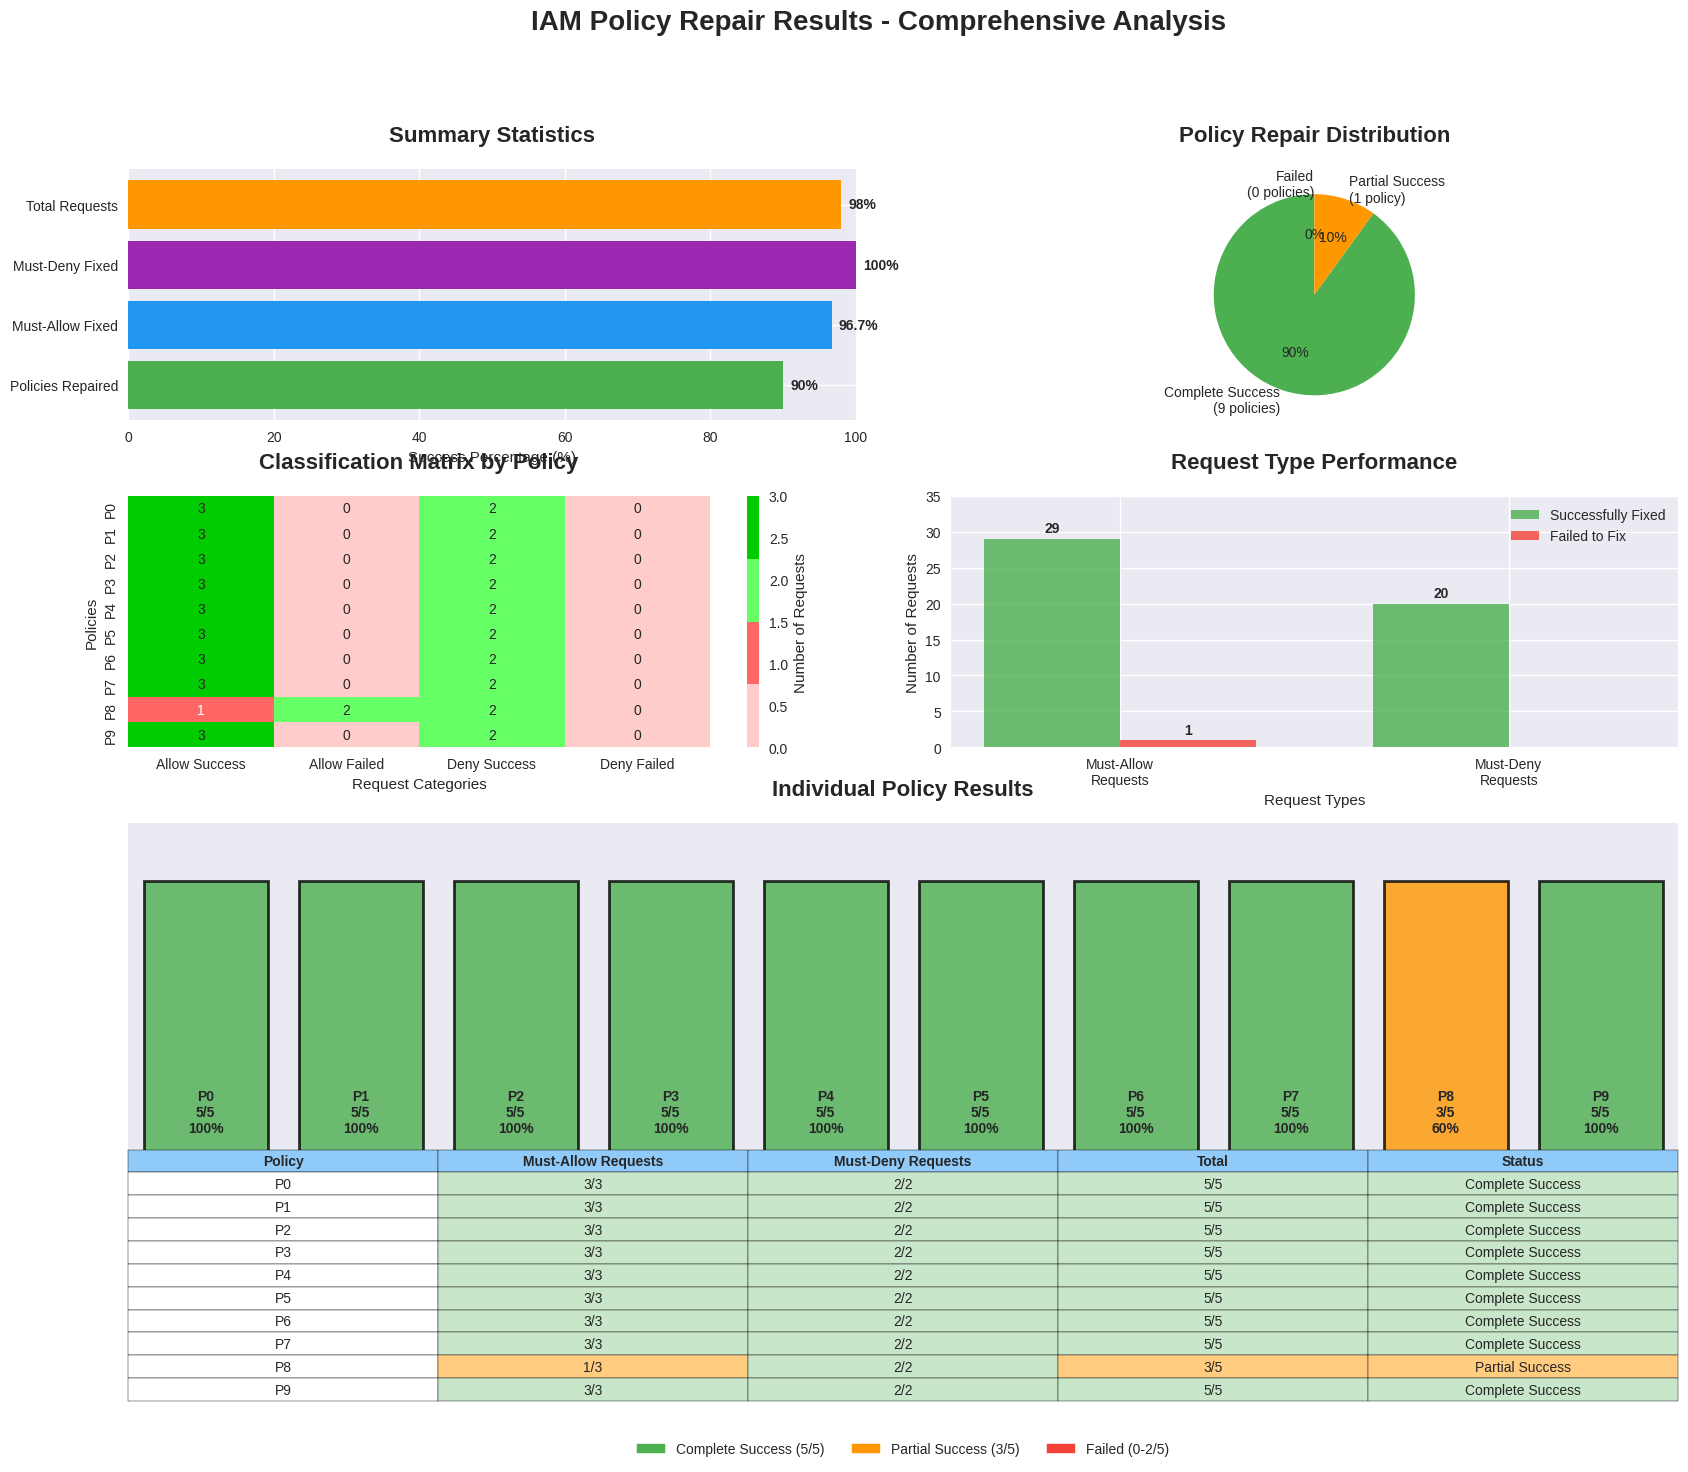

IAM POLICY REPAIR RESULTS SUMMARY
Total Policies: 10
Successfully Repaired: 9 (90%)
Partially Repaired: 1 (10%)
Failed: 0 (0%)

Request Type Breakdown:
Must-Allow Requests: 29/30 fixed (96.7%)
Must-Deny Requests: 20/20 fixed (100%)
Overall Success Rate: 49/50 (98%)

Policy-by-Policy Results:
P0: 3/3 allow, 2/2 deny, 5/5 total ✓ Complete
P1: 3/3 allow, 2/2 deny, 5/5 total ✓ Complete
P2: 3/3 allow, 2/2 deny, 5/5 total ✓ Complete
P3: 3/3 allow, 2/2 deny, 5/5 total ✓ Complete
P4: 3/3 allow, 2/2 deny, 5/5 total ✓ Complete
P5: 3/3 allow, 2/2 deny, 5/5 total ✓ Complete
P6: 3/3 allow, 2/2 deny, 5/5 total ✓ Complete
P7: 3/3 allow, 2/2 deny, 5/5 total ✓ Complete
P8: 1/3 allow, 2/2 deny, 3/5 total ⚠ Partial
P9: 3/3 allow, 2/2 deny, 5/5 total ✓ Complete


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib.patches import Rectangle
import matplotlib.patches as mpatches

# Set style for better looking plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Data setup
policies = [f'P{i}' for i in range(10)]
must_allow_success = [3, 3, 3, 3, 3, 3, 3, 3, 1, 3]  # P8 has only 1/3
must_deny_success = [2, 2, 2, 2, 2, 2, 2, 2, 2, 2]   # All policies have 2/2

# Create figure with subplots
fig = plt.figure(figsize=(20, 16))
gs = fig.add_gridspec(4, 4, hspace=0.3, wspace=0.3)

# Color scheme
colors = {
    'success': '#4CAF50',
    'partial': '#FF9800', 
    'failure': '#F44336',
    'must_allow': '#2196F3',
    'must_deny': '#9C27B0'
}

# 1. Summary Statistics (Top Left)
ax1 = fig.add_subplot(gs[0, :2])
summary_data = {
    'Policies Repaired': f'9/10 (90%)',
    'Must-Allow Fixed': f'29/30 (96.7%)',
    'Must-Deny Fixed': f'20/20 (100%)',
    'Total Requests': f'49/50 (98%)'
}

y_pos = np.arange(len(summary_data))
values = [90, 96.7, 100, 98]
bars = ax1.barh(y_pos, values, color=[colors['success'], colors['must_allow'], 
                                     colors['must_deny'], colors['partial']])

ax1.set_yticks(y_pos)
ax1.set_yticklabels(list(summary_data.keys()))
ax1.set_xlabel('Success Percentage (%)')
ax1.set_title('Summary Statistics', fontsize=16, fontweight='bold', pad=20)
ax1.set_xlim(0, 100)

# Add percentage labels on bars
for i, (bar, value) in enumerate(zip(bars, values)):
    ax1.text(value + 1, i, f'{value}%', va='center', fontweight='bold')

# 2. Policy Success Distribution Pie Chart (Top Right)
ax2 = fig.add_subplot(gs[0, 2:])
success_counts = [9, 1, 0]  # Complete, Partial, Failed
labels = ['Complete Success\n(9 policies)', 'Partial Success\n(1 policy)', 'Failed\n(0 policies)']
pie_colors = [colors['success'], colors['partial'], colors['failure']]

wedges, texts, autotexts = ax2.pie(success_counts, labels=labels, colors=pie_colors, 
                                  autopct='%1.0f%%', startangle=90, textprops={'fontsize': 10})
ax2.set_title('Policy Repair Distribution', fontsize=16, fontweight='bold', pad=20)

# 3. Classification Matrix Heatmap (Middle Left)
ax3 = fig.add_subplot(gs[1, :2])

# Create matrix data
matrix_data = []
for i in range(10):
    policy_data = [must_allow_success[i], 3 - must_allow_success[i], 
                   must_deny_success[i], 2 - must_deny_success[i]]
    matrix_data.append(policy_data)

matrix_df = pd.DataFrame(matrix_data, 
                        columns=['Allow Success', 'Allow Failed', 'Deny Success', 'Deny Failed'],
                        index=policies)

# Create custom colormap
from matplotlib.colors import LinearSegmentedColormap
colors_list = ['#ffcccc', '#ff6666', '#66ff66', '#00cc00']
n_bins = 4
cmap = LinearSegmentedColormap.from_list('custom', colors_list, N=n_bins)

sns.heatmap(matrix_df, annot=True, fmt='d', cmap=cmap, 
           cbar_kws={'label': 'Number of Requests'}, ax=ax3)
ax3.set_title('Classification Matrix by Policy', fontsize=16, fontweight='bold', pad=20)
ax3.set_xlabel('Request Categories')
ax3.set_ylabel('Policies')

# 4. Request Type Performance (Middle Right)
ax4 = fig.add_subplot(gs[1, 2:])

categories = ['Must-Allow\nRequests', 'Must-Deny\nRequests']
successful = [29, 20]
failed = [1, 0]
total = [30, 20]

x = np.arange(len(categories))
width = 0.35

bars1 = ax4.bar(x - width/2, successful, width, label='Successfully Fixed', 
               color=colors['success'], alpha=0.8)
bars2 = ax4.bar(x + width/2, failed, width, label='Failed to Fix', 
               color=colors['failure'], alpha=0.8)

ax4.set_xlabel('Request Types')
ax4.set_ylabel('Number of Requests')
ax4.set_title('Request Type Performance', fontsize=16, fontweight='bold', pad=20)
ax4.set_xticks(x)
ax4.set_xticklabels(categories)
ax4.legend()
ax4.set_ylim(0, 35)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax4.text(bar.get_x() + bar.get_width()/2., height + 0.5, f'{int(height)}',
                    ha='center', va='bottom', fontweight='bold')

# 5. Individual Policy Results Grid (Bottom)
ax5 = fig.add_subplot(gs[2:, :])

# Create a grid visualization
grid_size = 10
x_positions = np.arange(grid_size)
y_position = 0

# Calculate success rates for each policy
policy_success_rates = [(must_allow_success[i] + must_deny_success[i]) / 5 * 100 
                       for i in range(10)]

# Create rectangles for each policy
for i, (policy, rate) in enumerate(zip(policies, policy_success_rates)):
    if rate == 100:
        color = colors['success']
        status = 'Complete'
    elif rate >= 60:
        color = colors['partial']
        status = 'Partial'
    else:
        color = colors['failure']
        status = 'Failed'
    
    # Create rectangle
    rect = Rectangle((x_positions[i] - 0.4, y_position - 0.4), 0.8, 0.8, 
                    facecolor=color, alpha=0.8, edgecolor='black', linewidth=2)
    ax5.add_patch(rect)
    
    # Add policy label
    ax5.text(x_positions[i], y_position, f'{policy}\n{must_allow_success[i]+must_deny_success[i]}/5\n{rate:.0f}%', 
            ha='center', va='center', fontweight='bold', fontsize=10)

ax5.set_xlim(-0.5, 9.5)
ax5.set_ylim(-0.5, 0.5)
ax5.set_xticks([])
ax5.set_yticks([])
ax5.set_title('Individual Policy Results', fontsize=16, fontweight='bold', pad=20)

# Add legend for policy grid
legend_elements = [
    mpatches.Patch(color=colors['success'], label='Complete Success (5/5)'),
    mpatches.Patch(color=colors['partial'], label='Partial Success (3/5)'),
    mpatches.Patch(color=colors['failure'], label='Failed (0-2/5)')
]
ax5.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=3)

# 6. Detailed Results Table
ax6 = fig.add_subplot(gs[3, :])
ax6.axis('tight')
ax6.axis('off')

# Create table data
table_data = []
for i in range(10):
    total_success = must_allow_success[i] + must_deny_success[i]
    status = 'Complete Success' if total_success == 5 else 'Partial Success'
    table_data.append([
        f'P{i}', 
        f'{must_allow_success[i]}/3', 
        f'{must_deny_success[i]}/2', 
        f'{total_success}/5',
        status
    ])

table = ax6.table(cellText=table_data,
                 colLabels=['Policy', 'Must-Allow Requests', 'Must-Deny Requests', 'Total', 'Status'],
                 cellLoc='center',
                 loc='center',
                 bbox=[0, 0, 1, 1])

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

# Color code the table cells
for i in range(len(table_data)):
    for j in range(len(table_data[i])):
        cell = table[(i+1, j)]
        if j == 4:  # Status column
            if 'Complete' in table_data[i][j]:
                cell.set_facecolor('#c8e6c9')
            else:
                cell.set_facecolor('#ffcc80')
        elif j in [1, 2, 3]:  # Score columns
            if '/' in table_data[i][j]:
                achieved, total = map(int, table_data[i][j].split('/'))
                if achieved == total:
                    cell.set_facecolor('#c8e6c9')
                elif achieved > 0:
                    cell.set_facecolor('#ffcc80')
                else:
                    cell.set_facecolor('#ffcdd2')

# Style header
for j in range(5):
    table[(0, j)].set_facecolor('#90caf9')
    table[(0, j)].set_text_props(weight='bold')

plt.suptitle('IAM Policy Repair Results - Comprehensive Analysis', 
             fontsize=20, fontweight='bold', y=0.98)

#save
plt.savefig('iam_policy_repair_results.png', bbox_inches='tight', dpi=300)

plt.tight_layout()
plt.show()

# Print summary statistics
print("="*60)
print("IAM POLICY REPAIR RESULTS SUMMARY")
print("="*60)
print(f"Total Policies: 10")
print(f"Successfully Repaired: 9 (90%)")
print(f"Partially Repaired: 1 (10%)")
print(f"Failed: 0 (0%)")
print()
print("Request Type Breakdown:")
print(f"Must-Allow Requests: 29/30 fixed (96.7%)")
print(f"Must-Deny Requests: 20/20 fixed (100%)")
print(f"Overall Success Rate: 49/50 (98%)")
print()
print("Policy-by-Policy Results:")
for i in range(10):
    total = must_allow_success[i] + must_deny_success[i]
    status = "✓ Complete" if total == 5 else "⚠ Partial"
    print(f"P{i}: {must_allow_success[i]}/3 allow, {must_deny_success[i]}/2 deny, {total}/5 total {status}")
print("="*60)

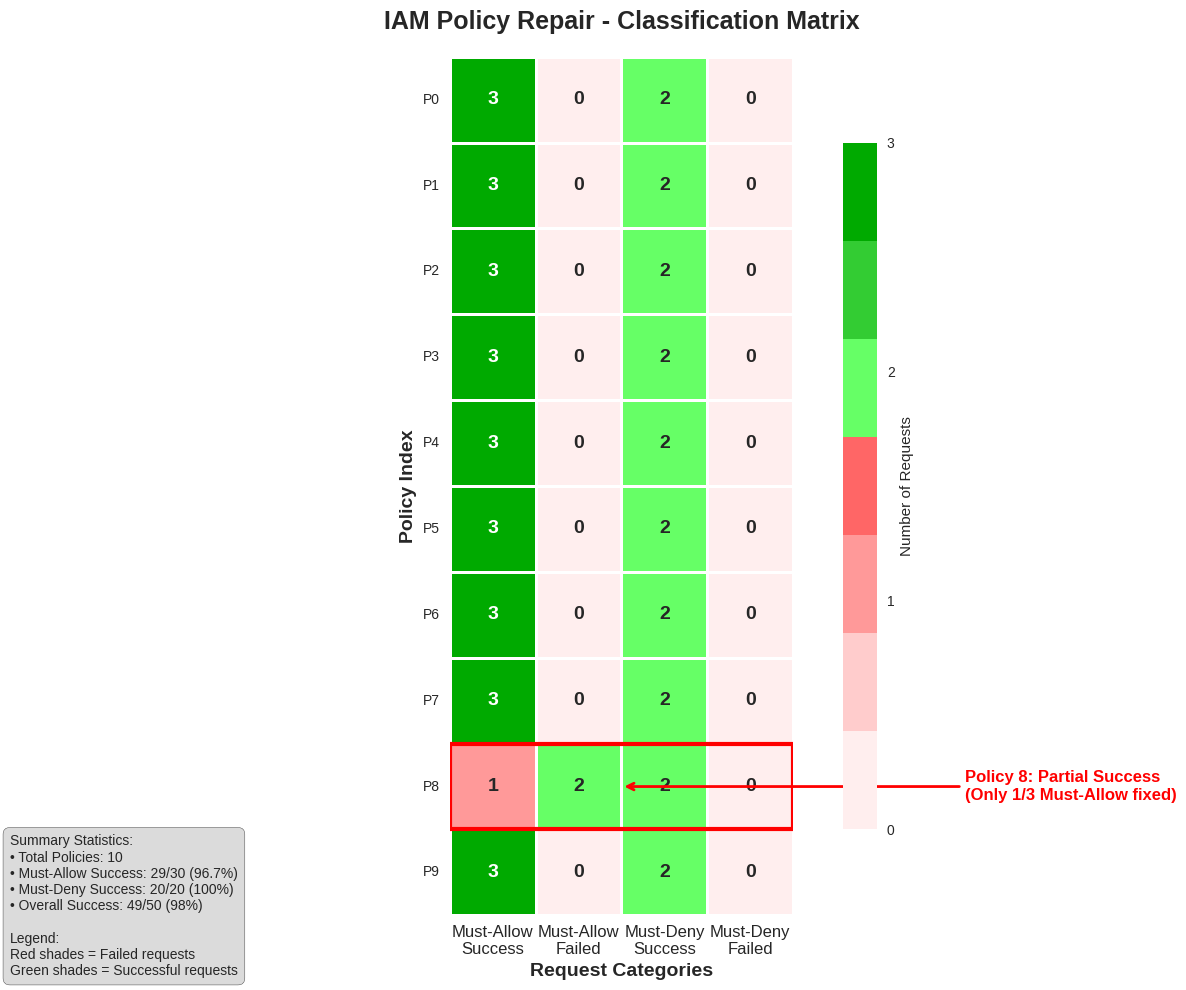

CLASSIFICATION MATRIX - DETAILED BREAKDOWN
Policy   Must-Allow      Must-Deny       Total Success   Status
--------------------------------------------------------------------------------
P0       3/3 ( 100%)   2/2 ( 100%)   5/5 ( 100%)   ✓ Complete
P1       3/3 ( 100%)   2/2 ( 100%)   5/5 ( 100%)   ✓ Complete
P2       3/3 ( 100%)   2/2 ( 100%)   5/5 ( 100%)   ✓ Complete
P3       3/3 ( 100%)   2/2 ( 100%)   5/5 ( 100%)   ✓ Complete
P4       3/3 ( 100%)   2/2 ( 100%)   5/5 ( 100%)   ✓ Complete
P5       3/3 ( 100%)   2/2 ( 100%)   5/5 ( 100%)   ✓ Complete
P6       3/3 ( 100%)   2/2 ( 100%)   5/5 ( 100%)   ✓ Complete
P7       3/3 ( 100%)   2/2 ( 100%)   5/5 ( 100%)   ✓ Complete
P8       1/3 (  33%)   2/2 ( 100%)   3/5 (  60%)   ⚠ Partial
P9       3/3 ( 100%)   2/2 ( 100%)   5/5 ( 100%)   ✓ Complete
TOTAL:   29/30 (96.7%)    20/20 (100%)    49/50 (98.0%)    9 Complete, 1 Partial


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Set style for better looking plots
plt.style.use('seaborn-v0_8')

# Data setup
policies = [f'P{i}' for i in range(10)]
must_allow_success = [3, 3, 3, 3, 3, 3, 3, 3, 1, 3]  # P8 has only 1/3
must_deny_success = [2, 2, 2, 2, 2, 2, 2, 2, 2, 2]   # All policies have 2/2

# Create the classification matrix data
matrix_data = []
for i in range(10):
    policy_data = [
        must_allow_success[i],      # Allow Success
        3 - must_allow_success[i],  # Allow Failed  
        must_deny_success[i],       # Deny Success
        2 - must_deny_success[i]    # Deny Failed
    ]
    matrix_data.append(policy_data)

# Create DataFrame
matrix_df = pd.DataFrame(
    matrix_data, 
    columns=['Must-Allow\nSuccess', 'Must-Allow\nFailed', 'Must-Deny\nSuccess', 'Must-Deny\nFailed'],
    index=policies
)

# Create figure
plt.figure(figsize=(12, 10))

# Create custom colormap - using discrete colors for better interpretation
from matplotlib.colors import ListedColormap
colors = ['#ffeeee', '#ffcccc', '#ff9999', '#ff6666', '#66ff66', '#33cc33', '#00aa00']
cmap = ListedColormap(colors)

# Create the heatmap
ax = sns.heatmap(
    matrix_df, 
    annot=True, 
    fmt='d', 
    cmap=cmap,
    vmin=0,
    vmax=3,
    cbar_kws={
        'label': 'Number of Requests',
        'shrink': 0.8,
        'ticks': [0, 1, 2, 3]
    },
    square=True,
    linewidths=1,
    linecolor='white',
    annot_kws={'size': 14, 'weight': 'bold'}
)

# Customize the plot
plt.title('IAM Policy Repair - Classification Matrix', 
          fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Request Categories', fontsize=14, fontweight='bold')
plt.ylabel('Policy Index', fontsize=14, fontweight='bold')

# Rotate x-axis labels for better readability
plt.xticks(rotation=0, ha='center', fontsize=12)
plt.yticks(rotation=0)

# Add a text box with summary statistics
summary_text = """Summary Statistics:
• Total Policies: 10
• Must-Allow Success: 29/30 (96.7%)
• Must-Deny Success: 20/20 (100%)
• Overall Success: 49/50 (98%)

Legend:
Red shades = Failed requests
Green shades = Successful requests"""

plt.figtext(0.02, 0.02, summary_text, fontsize=10, 
           bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", alpha=0.8))

# Highlight Policy 8 (the problematic one) with a border
ax.add_patch(plt.Rectangle((0, 8), 4, 1, fill=False, edgecolor='red', lw=3))

# Add arrow pointing to Policy 8
ax.annotate('Policy 8: Partial Success\n(Only 1/3 Must-Allow fixed)', 
           xy=(2, 8.5), xytext=(6, 8.5),
           arrowprops=dict(arrowstyle='->', color='red', lw=2),
           fontsize=12, fontweight='bold', color='red',
           ha='left', va='center')

plt.tight_layout()
plt.savefig('classification_matrix_hdpi.png', dpi=300, bbox_inches='tight')

plt.show()

#save the figure in hdpi format

# Print detailed matrix information
print("="*80)
print("CLASSIFICATION MATRIX - DETAILED BREAKDOWN")
print("="*80)
print(f"{'Policy':<8} {'Must-Allow':<15} {'Must-Deny':<15} {'Total Success':<15} {'Status'}")
print("-" * 80)

for i in range(10):
    allow_success = must_allow_success[i]
    deny_success = must_deny_success[i]
    total_success = allow_success + deny_success
    
    status = "✓ Complete" if total_success == 5 else "⚠ Partial"

    print(f"P{i:<7} {allow_success}/3 ({allow_success/3*100:4.0f}%)   "
          f"{deny_success}/2 ({deny_success/2*100:4.0f}%)   "
          f"{total_success}/5 ({total_success/5*100:4.0f}%)   {status}")

print("="*80)
print(f"TOTAL:   29/30 (96.7%)    20/20 (100%)    49/50 (98.0%)    9 Complete, 1 Partial")
print("="*80)

In [ ]:
class RequestGenerator:
    def __init__(self, policy: Dict[str, Any]):
        self.policy = policy
        
    def generate_must_allow_requests(self, num_requests):
        
        allowed_requests = []
        actions = self.policy.get("Statement", [{}])[0].get("Action", [])
        resources = self.policy.get("Statement", [{}])[0].get("Resource", [])
        
        for _ in range(num_requests):
            request = {
                "Effect": "Allow",
                "Action": random.choice(actions) if actions else "s3:GetObject",
                "Resource": random.choice(resources) if resources else "arn:aws:s3:::example-bucket/*",
                "Principal": "bob"
            }
            allowed_requests.append(request)
        return allowed_requests
    
    def generate_must_deny_requests(self, num_requests):
        #from the allowed requests, generate denied requests by modifying actions or resources
        denied_requests = []
        allowed_requests = self.generate_must_allow_requests(num_requests)
        for request in allowed_requests:
            denied_request = request.copy()
            # Change action to something not allowed
            denied_request["Action"] = "s3:DeleteObject"
            denied_requests.append(denied_request)
            denied_request["Resource"] = "arn:aws:s3:::example-bucket/forbidden/*"
            denied_requests.append(denied_request)
        return denied_requests

In [ ]:
import json
import random
import uuid
from typing import Dict, List, Any, Optional

class RequestGenerator:
    def __init__(self, policy: Dict[str, Any]):
        self.policy = policy
        self.alternative_actions = [
            "s3:PutObject", "s3:DeleteObject", "s3:CreateBucket", "s3:DeleteBucket",
            "s3:PutBucketPolicy", "s3:ListAllMyBuckets", "s3:GetBucketAcl",
            "ec2:DescribeInstances", "ec2:RunInstances", "ec2:TerminateInstances",
            "iam:CreateUser", "iam:DeleteUser", "iam:AttachUserPolicy", "iam:ListUsers",
            "lambda:InvokeFunction", "lambda:CreateFunction", "lambda:DeleteFunction",
            "dynamodb:PutItem", "dynamodb:DeleteItem", "dynamodb:GetItem", "dynamodb:Scan",
            "rds:DescribeDBInstances", "rds:CreateDBInstance", "rds:DeleteDBInstance",
            "cloudwatch:PutMetricData", "cloudwatch:GetMetricStatistics", "cloudwatch:ListMetrics",
            "sns:Publish", "sns:CreateTopic", "sqs:SendMessage", "sqs:ReceiveMessage"
        ]
        self.alternative_resources = [
            "arn:aws:s3:::production-data/*",
            "arn:aws:s3:::backup-bucket/*", 
            "arn:aws:s3:::logs-archive/*",
            "arn:aws:s3:::company-files/*",
            "arn:aws:s3:::user-uploads/*",
            "admin-data/*",
            "system-config/*",
            "temp-storage/*",
            "analytics-data/*",
            "arn:aws:ec2:us-east-1:123456789012:instance/*",
            "arn:aws:iam::123456789012:user/*",
            "arn:aws:lambda:us-east-1:123456789012:function:data-processor",
            "arn:aws:dynamodb:us-east-1:123456789012:table/Users",
            "arn:aws:rds:us-east-1:123456789012:db:production"
        ]
        self.other_principals = ["alice", "charlie", "admin", "serviceuser", "developer"]
    
    def extract_policy_elements(self) -> Dict[str, List[str]]:
        """Extract actions, resources, and principals from the policy"""
        elements = {
            "actions": [],
            "resources": [],
            "principals": []
        }
        
        statements = self.policy.get("Statement", [])
        for statement in statements:
            if statement.get("Effect") == "Allow":
                # Extract actions
                actions = statement.get("Action", [])
                if isinstance(actions, str):
                    elements["actions"].append(actions)
                elif isinstance(actions, list):
                    elements["actions"].extend(actions)
                
                # Extract resources
                resources = statement.get("Resource", [])
                if isinstance(resources, str):
                    elements["resources"].append(resources)
                elif isinstance(resources, list):
                    elements["resources"].extend(resources)
                
                # Extract principals
                principal = statement.get("Principal")
                if isinstance(principal, str):
                    elements["principals"].append(principal)
                elif isinstance(principal, list):
                    elements["principals"].extend(principal)
        
        return elements
    
    def generate_denied_action_variations(self, allowed_actions: List[str]) -> List[str]:
        """Generate actions that should be denied by modifying allowed actions"""
        denied_actions = []
        
        for action in allowed_actions:
            service, operation = action.split(":", 1)
            
            # Generate variations within the same service that aren't allowed
            if service == "s3":
                if "GetObject" in operation:
                    denied_actions.extend(["s3:PutObject", "s3:DeleteObject", "s3:CreateBucket"])
                elif "ListBucket" in operation:
                    denied_actions.extend(["s3:DeleteBucket", "s3:PutBucketPolicy", "s3:GetBucketAcl"])
                else:
                    denied_actions.extend(["s3:PutObject", "s3:DeleteObject"])
            elif service == "ec2":
                denied_actions.extend(["ec2:RunInstances", "ec2:TerminateInstances", "ec2:CreateSecurityGroup"])
            elif service == "iam":
                denied_actions.extend(["iam:CreateUser", "iam:DeleteUser", "iam:AttachUserPolicy"])
            else:
                # For other services, add different operations
                denied_actions.extend([f"{service}:CreateResource", f"{service}:DeleteResource"])
            
            # Also add actions from completely different services
            if service != "lambda":
                denied_actions.append("lambda:InvokeFunction")
            if service != "dynamodb":
                denied_actions.append("dynamodb:PutItem")
            if service != "rds":
                denied_actions.append("rds:CreateDBInstance")
        
        return list(set(denied_actions))
    
    def generate_denied_resource_variations(self, allowed_resources: List[str]) -> List[str]:
        """Generate resources that should be denied by modifying allowed resources"""
        denied_resources = []
        
        for resource in allowed_resources:
            if resource.endswith("/*"):
                # For wildcard paths, create resources outside the allowed path
                base_path = resource[:-2]
                denied_resources.extend([
                    base_path + "-forbidden/file.txt",  # Similar but different path
                    base_path.replace("/", "-forbidden/") + "/file.txt",  # Modified path structure
                    "arn:aws:s3:::different-bucket/*",  # Different bucket entirely
                ])
            elif "arn:aws:s3:::" in resource:
                # For S3 resources, create variations
                if "/" in resource:
                    bucket_part, file_part = resource.rsplit("/", 1)
                    denied_resources.extend([
                        bucket_part.replace(":::", ":::forbidden-") + "/" + file_part,  # Different bucket
                        bucket_part + "/forbidden-" + file_part,  # Different file
                    ])
                denied_resources.append("arn:aws:s3:::completely-different-bucket/file.txt")
            else:
                # For simple paths, create variations
                denied_resources.extend([
                    "forbidden-" + resource,
                    resource + "-forbidden",
                    resource.replace("/", "/forbidden/") if "/" in resource else "forbidden/" + resource
                ])
        
        # Add some completely different resource types
        denied_resources.extend([
            "arn:aws:ec2:us-east-1:123456789012:instance/i-1234567890abcdef0",
            "arn:aws:iam::123456789012:user/unauthorized-user",
            "arn:aws:lambda:us-east-1:123456789012:function:forbidden-function"
        ])
        
        return list(set(denied_resources))  # Remove duplicates
    
    def generate_denied_principals(self, allowed_principals: List[str]) -> List[str]:
        """Generate principals that should be denied"""
        if not allowed_principals:
            return []
        
        denied_principals = []
        
        for principal in allowed_principals:
            # Create variations of the allowed principal
            denied_principals.extend([
                principal + "-forbidden",
                "fake-" + principal,
                principal.replace(principal[0], principal[0].upper()) if principal[0].islower() else principal.replace(principal[0], principal[0].lower())
            ])
        
        # Add some completely different principals
        denied_principals.extend(["unauthorized-user", "hacker", "external-user", "temp-user"])
        
        return list(set(denied_principals))  # Remove duplicates
    
    def generate_valid_resource_variations(self, base_resource: str) -> List[str]:
        """Generate valid resource variations based on wildcards"""
        variations = [base_resource]
        
        if base_resource.endswith("/*"):
            # Generate specific files under the wildcard path
            base_path = base_resource[:-2]  # Remove /*
            variations.extend([
                f"{base_path}/users/john-doe/config.json",
                f"{base_path}/prod/database-backup.sql", 
                f"{base_path}/logs/2024/application.log",
                f"{base_path}/temp/upload-12345.tmp",
                f"{base_path}/reports/quarterly-summary.pdf"
            ])
        elif base_resource.endswith("*"):
            # Generate variations for simple wildcard
            base_path = base_resource[:-1]  # Remove *
            variations.extend([
                f"{base_path}file1",
                f"{base_path}document",
                f"{base_path}data123"
            ])
        
        return variations
    
    def expand_wildcard_action(self, action: str) -> str:
        """Convert wildcard actions to specific actions"""
        if not action.endswith("*"):
            return action
            
        service = action.split(":")[0]
        if service == "s3":
            return random.choice(["s3:GetObject", "s3:ListBucket", "s3:GetBucketLocation", "s3:PutObject"])
        elif service == "ec2":
            return random.choice(["ec2:DescribeInstances", "ec2:RunInstances", "ec2:TerminateInstances"])
        elif service == "iam":
            return random.choice(["iam:CreateUser", "iam:DeleteUser", "iam:ListUsers"])
        elif service == "lambda":
            return random.choice(["lambda:InvokeFunction", "lambda:CreateFunction"])
        else:
            # Default to s3 action if unknown service
            return "s3:GetObject"
    
    def expand_wildcard_resource(self, resource: str) -> str:
        """Convert wildcard resources to specific resources"""
        if resource == "*":
            return "arn:aws:s3:::my-bucket/specific-file.txt"
        elif resource.endswith("/*"):
            base_path = resource[:-2]
            suffixes = ["/document.txt", "/data/file.json", "/images/photo.jpg", "/logs/app.log"]
            return base_path + random.choice(suffixes)
        elif resource.endswith("*"):
            base_path = resource[:-1]
            suffixes = ["file1", "document", "data123"]
            return base_path + random.choice(suffixes)
        else:
            return resource

    def generate_must_allow_requests(self, num_requests: int) -> List[Dict[str, Any]]:
        """Generate requests that must be allowed by the policy"""
        allowed_requests = []
        policy_elements = self.extract_policy_elements()
        
        if not policy_elements["actions"]:
            raise ValueError("No allowed actions found in policy")
        
        for i in range(num_requests):
            # Select allowed action and expand wildcards
            base_action = random.choice(policy_elements["actions"])
            action = self.expand_wildcard_action(base_action)
            
            # Select allowed resource and expand wildcards
            if policy_elements["resources"]:
                base_resource = random.choice(policy_elements["resources"])
                resource = self.expand_wildcard_resource(base_resource)
            else:
                resource = "arn:aws:s3:::my-bucket/specific-file.txt"  # Default specific resource
            
            # Select allowed principal
            principal = None
            if policy_elements["principals"]:
                principal = random.choice(policy_elements["principals"])
            
            request = {
                "id": f"allow_{uuid.uuid4().hex[:8]}",
                "request": {
                    "Effect": "Allow",
                    "Action": [action],
                    "Resource": [resource]
                },
                "expected_result": "ALLOW"
            }
            
            if principal:
                request["request"]["Principal"] = principal
            
            allowed_requests.append(request)
        
        return allowed_requests
    
    def generate_must_deny_requests(self, num_requests: int) -> List[Dict[str, Any]]:
        """Generate requests that must be denied by the policy"""
        denied_requests = []
        policy_elements = self.extract_policy_elements()
        
        # Generate denied variations based on what's actually allowed
        denied_actions = self.generate_denied_action_variations(policy_elements["actions"])
        denied_resources = self.generate_denied_resource_variations(policy_elements["resources"])
        denied_principals = self.generate_denied_principals(policy_elements["principals"])
        
        for i in range(num_requests):
            # Randomly pick which element to make invalid
            strategies = ["denied_action", "denied_resource"]
            if denied_principals:  # Only include principal strategy if we have denied principals
                strategies.append("denied_principal")
            
            strategy = random.choice(strategies)
            
            if strategy == "denied_action" and denied_actions:
                action = random.choice(denied_actions)
                # Use allowed resource and principal
                base_resource = random.choice(policy_elements["resources"]) if policy_elements["resources"] else "arn:aws:s3:::my-bucket/file.txt"
                resource = self.expand_wildcard_resource(base_resource)
                principal = random.choice(policy_elements["principals"]) if policy_elements["principals"] else None
                
            elif strategy == "denied_resource" and denied_resources:
                # Use allowed action and principal
                base_action = random.choice(policy_elements["actions"]) if policy_elements["actions"] else "s3:GetObject"
                action = self.expand_wildcard_action(base_action)
                resource = self.expand_wildcard_resource(random.choice(denied_resources))
                principal = random.choice(policy_elements["principals"]) if policy_elements["principals"] else None
                
            elif strategy == "denied_principal" and denied_principals:
                # Use allowed action and resource
                base_action = random.choice(policy_elements["actions"]) if policy_elements["actions"] else "s3:GetObject"
                action = self.expand_wildcard_action(base_action)
                base_resource = random.choice(policy_elements["resources"]) if policy_elements["resources"] else "arn:aws:s3:::my-bucket/file.txt"
                resource = self.expand_wildcard_resource(base_resource)
                principal = random.choice(denied_principals)
                
            else:
                # Fallback: use denied action
                action = random.choice(denied_actions) if denied_actions else "lambda:InvokeFunction"
                base_resource = random.choice(policy_elements["resources"]) if policy_elements["resources"] else "arn:aws:s3:::my-bucket/file.txt"
                resource = self.expand_wildcard_resource(base_resource)
                principal = random.choice(policy_elements["principals"]) if policy_elements["principals"] else None
            
            request = {
                "id": f"deny_{uuid.uuid4().hex[:8]}",
                "request": {
                    "Effect": "Allow",
                    "Action": [action],
                    "Resource": [resource]
                },
                "expected_result": "DENY"
            }
            
            if principal:
                request["request"]["Principal"] = principal
            
            denied_requests.append(request)
        
        return denied_requests
    
    def generate_all_requests(self, num_allow: int = 3, num_deny: int = 2) -> Dict[str, Any]:
        """Generate complete set of must-allow and must-deny requests"""
        try:
            must_allow = self.generate_must_allow_requests(num_allow)
            must_deny = self.generate_must_deny_requests(num_deny)
            
            # Combine all requests - FIRST allowed, THEN denied
            all_requests = []
            
            # Add allowed requests first
            for request in must_allow:
                formatted_request = {
                    "id": request["id"],
                    "Effect": "allow",
                    "Action": request["request"]["Action"],
                    "Resource": request["request"]["Resource"]
                }
                if "Principal" in request["request"]:
                    formatted_request["Principal"] = request["request"]["Principal"]
                all_requests.append(formatted_request)
            
            # Add denied requests second
            for request in must_deny:
                formatted_request = {
                    "id": request["id"],
                    "Effect": "deny",
                    "Action": request["request"]["Action"], 
                    "Resource": request["request"]["Resource"]
                }
                if "Principal" in request["request"]:
                    formatted_request["Principal"] = request["request"]["Principal"]
                all_requests.append(formatted_request)
            
            return {
                "Requests": all_requests
            }
        except Exception as e:
            return {
                "error": f"Failed to generate requests: {str(e)}"
            }

# Example usage
def main():
    # Example policy
    policy = {
    "Version": "2012-10-17",
    "Statement": [
        {
            "Sid": "VisualEditor0",
            "Effect": "Allow",
            "Action": [
                "s3:*"
            ],
            "Resource": [
                "arn:aws:s3:::bucket",
                "arn:aws:s3:::bucket/*"
            ]
        },
        {
            "Sid": "List",
            "Effect": "Allow",
            "Action": "s3:ListAllMyBuckets",
            "Resource": "*"
        },
        {
            "Sid": "CloudWatch",
            "Effect": "Allow",
            "Action": [
                "cloudwatch:ListMetrics",
                "cloudwatch:GetMetricStatistics"
            ],
            "Resource": "*"
        },
        {
            "Sid": "List",
            "Effect": "Deny",
            "Action": "s3:ListAllMyBuckets",
            "Resource": "*"
        }
    ]
}

    
    generator = RequestGenerator(policy)
    test_data = generator.generate_all_requests(num_allow=3, num_deny=2)
    
    print(json.dumps(test_data, indent=2))
    return test_data

if __name__ == "__main__":
    main()

{
  "Requests": [
    {
      "id": "allow_2244ec71",
      "Effect": "allow",
      "Action": [
        "s3:GetObject"
      ],
      "Resource": [
        "arn:aws:s3:::my-bucket/specific-file.txt"
      ]
    },
    {
      "id": "allow_a7425279",
      "Effect": "allow",
      "Action": [
        "cloudwatch:ListMetrics"
      ],
      "Resource": [
        "arn:aws:s3:::bucket/images/photo.jpg"
      ]
    },
    {
      "id": "allow_89f69f5f",
      "Effect": "allow",
      "Action": [
        "s3:ListAllMyBuckets"
      ],
      "Resource": [
        "arn:aws:s3:::bucket/data/file.json"
      ]
    },
    {
      "id": "deny_b522e4ca",
      "Effect": "deny",
      "Action": [
        "rds:CreateDBInstance"
      ],
      "Resource": [
        "arn:aws:s3:::bucket"
      ]
    },
    {
      "id": "deny_d27ade2b",
      "Effect": "deny",
      "Action": [
        "cloudwatch:ListMetrics"
      ],
      "Resource": [
        "forbidden-document"
      ]
    }
  ]
}


In [3]:
import json
import os
import uuid
from pathlib import Path

def merge_request_files():
    """Merge request files in predefined groups of 5, with proper allow/deny IDs"""
    
    # Define the file groups (each group is a set of 5 consecutive files)
    file_groups = [
        [0, 1, 2, 3, 4],       # 00-04
        [10, 11, 12, 13, 14],  # 10-14
        [20, 21, 22, 23, 24],  # 20-24
        [30, 31, 32, 33, 34],  # 30-34
        [40, 41, 42, 43, 44],  # 40-44
        [50, 51, 52, 53, 54],  # 50-54
        [60, 61, 62, 63, 64],  # 60-64
        [70, 71, 72, 73, 74],  # 70-74
        [80, 81, 82, 83, 84],  # 80-84
        [90, 91, 92, 93, 94]   # 90-94
    ]
    
    # Input and output directories
    input_dir = Path("/home/bhall2/Documents/fixmypolicy/FL/Dataset/requests/version2")
    output_dir = input_dir / "merged_requests"
    if not input_dir.exists():
        raise FileNotFoundError(f"Input directory does not exist: {input_dir}")
    if not input_dir.is_dir():
        raise NotADirectoryError(f"Input path is not a directory: {input_dir}")
    if not output_dir.exists():
        print(f"Creating output directory: {output_dir}")
    output_dir.mkdir(exist_ok=True)
    
    print(f"Found {len(file_groups)} groups of 5 files each")
    
    # Process each group
    for group_idx, file_numbers in enumerate(file_groups):
        group_name = f"{file_numbers[0]:02d}-{file_numbers[-1]:02d}"
        print(f"\nProcessing group {group_idx + 1} ({group_name}): files {[f'{n:02d}' for n in file_numbers]}")
        
        merged_requests = []
        
        for req_idx, file_num in enumerate(file_numbers):
            input_file = input_dir / f"{file_num:02d}.json"
            
            try:
                with open(input_file, 'r') as f:
                    data = json.load(f)
                
                # Get the first request from this file
                requests = data.get("Requests", [])
                if requests:
                    original_request = requests[0].copy()
                    
                    # Assign new ID based on position in group
                    if req_idx < 3:  # First 3 are "allow" (positions 0, 1, 2)
                        new_id = f"allow_{uuid.uuid4().hex[:8]}"
                        original_request["Effect"] = "allow"
                    else:  # Last 2 are "deny" (positions 3, 4)
                        new_id = f"deny_{uuid.uuid4().hex[:8]}"
                        original_request["Effect"] = "deny"
                    
                    original_request["id"] = new_id
                    merged_requests.append(original_request)
                    
                    print(f"  Added {input_file.name} as {new_id} with effect '{original_request['Effect']}'")
                else:
                    print(f"  WARNING: No requests found in {input_file.name}")
                    
            except FileNotFoundError:
                print(f"  ERROR: File not found: {input_file}")
            except json.JSONDecodeError:
                print(f"  ERROR: Invalid JSON in {input_file}")
            except Exception as e:
                print(f"  ERROR processing {input_file}: {e}")
        
        # Save merged file
        if merged_requests:
            output_file = output_dir / f"merged_{group_name}.json"
            
            merged_data = {
                "Requests": merged_requests
            }
            
            with open(output_file, 'w') as f:
                json.dump(merged_data, f, indent=2)
            
            print(f"  Saved merged file: {output_file}")
            print(f"  Total requests in merged file: {len(merged_requests)}")
            print(f"  Allow requests: {sum(1 for r in merged_requests if r['Effect'] == 'allow')}")
            print(f"  Deny requests: {sum(1 for r in merged_requests if r['Effect'] == 'deny')}")
        else:
            print(f"  WARNING: No valid requests found for group {group_idx + 1}")
    
    print(f"\nMerging complete! Output files saved to: {output_dir}")
    return output_dir

def list_available_files():
    """List all available request files to verify"""
    input_dir = Path("/home/bhall2/Documents/fixmypolicy/FL/Dataset/requests/version2")
    
    file_groups = [
        [0, 1, 2, 3, 4],       # 00-04
        [10, 11, 12, 13, 14],  # 10-14
        [20, 21, 22, 23, 24],  # 20-24
        [30, 31, 32, 33, 34],  # 30-34
        [40, 41, 42, 43, 44],  # 40-44
        [50, 51, 52, 53, 54],  # 50-54
        [60, 61, 62, 63, 64],  # 60-64
        [70, 71, 72, 73, 74],  # 70-74
        [80, 81, 82, 83, 84],  # 80-84
        [90, 91, 92, 93, 94]   # 90-94
    ]
    
    print("Checking availability of request files by group:")
    total_available = 0
    complete_groups = 0
    
    for group_idx, file_numbers in enumerate(file_groups):
        group_name = f"{file_numbers[0]:02d}-{file_numbers[-1]:02d}"
        print(f"\nGroup {group_idx + 1} ({group_name}):")
        
        group_available = 0
        for file_num in file_numbers:
            file_path = input_dir / f"{file_num:02d}.json"
            if file_path.exists():
                print(f"  {file_num:02d}.json ✓")
                group_available += 1
                total_available += 1
            else:
                print(f"  {file_num:02d}.json ✗ (missing)")
        
        if group_available == 5:
            complete_groups += 1
            print(f"  Group {group_idx + 1}: COMPLETE ({group_available}/5)")
        else:
            print(f"  Group {group_idx + 1}: INCOMPLETE ({group_available}/5)")
    
    print(f"\nSummary:")
    print(f"Total files available: {total_available}")
    print(f"Complete groups: {complete_groups}/10")
    return complete_groups

if __name__ == "__main__":
    print("="*60)
    print("REQUEST FILE MERGER (Groups: 00-04, 10-14, 20-24, etc.)")
    print("="*60)
    
    # First, list available files
    complete_groups = list_available_files()
    
    print("\n" + "="*60)
    
    # Proceed with merging
    if complete_groups > 0:
        output_dir = merge_request_files()
        
        print(f"\n" + "="*60)
        print("SUMMARY")
        print("="*60)
        print(f"Merged files saved to: {output_dir}")
        print("Each merged file contains:")
        print("  - 5 requests total")
        print("  - First 3 requests: Effect='allow', ID starts with 'allow_'")
        print("  - Last 2 requests: Effect='deny', ID starts with 'deny_'")
        print(f"Merged file naming pattern: merged_XX-YY.json")
        print(f"Example: merged_00-04.json, merged_10-14.json, etc.")
    else:
        print("ERROR: No complete groups found")

REQUEST FILE MERGER (Groups: 00-04, 10-14, 20-24, etc.)
Checking availability of request files by group:

Group 1 (00-04):
  00.json ✓
  01.json ✓
  02.json ✓
  03.json ✓
  04.json ✓
  Group 1: COMPLETE (5/5)

Group 2 (10-14):
  10.json ✓
  11.json ✓
  12.json ✓
  13.json ✓
  14.json ✓
  Group 2: COMPLETE (5/5)

Group 3 (20-24):
  20.json ✓
  21.json ✓
  22.json ✓
  23.json ✓
  24.json ✓
  Group 3: COMPLETE (5/5)

Group 4 (30-34):
  30.json ✓
  31.json ✓
  32.json ✓
  33.json ✓
  34.json ✓
  Group 4: COMPLETE (5/5)

Group 5 (40-44):
  40.json ✓
  41.json ✓
  42.json ✓
  43.json ✓
  44.json ✓
  Group 5: COMPLETE (5/5)

Group 6 (50-54):
  50.json ✓
  51.json ✓
  52.json ✓
  53.json ✓
  54.json ✓
  Group 6: COMPLETE (5/5)

Group 7 (60-64):
  60.json ✓
  61.json ✓
  62.json ✓
  63.json ✓
  64.json ✓
  Group 7: COMPLETE (5/5)

Group 8 (70-74):
  70.json ✓
  71.json ✓
  72.json ✓
  73.json ✓
  74.json ✓
  Group 8: COMPLETE (5/5)

Group 9 (80-84):
  80.json ✓
  81.json ✓
  82.json ✓
  83.json